# **1. Perkenalan Dataset**


# Loan Prediction Dataset

Dataset ini merepresentasikan salah satu penerapan penting analitik data dalam industri keuangan, khususnya pada proses penilaian kelayakan pinjaman. Dengan total 615 baris data dan 13 variabel, dataset ini memberikan gambaran nyata tentang bagaimana perusahaan memanfaatkan data pelanggan untuk mendukung pengambilan keputusan. Setiap entri berisi informasi seperti jenis kelamin, status pernikahan, tingkat pendidikan, jumlah tanggungan, pendapatan, jumlah pinjaman, serta riwayat kredit, yang secara bersama-sama digunakan untuk menganalisis profil risiko peminjam. Studi terhadap dataset ini memungkinkan kita memahami variabel apa saja yang paling berpengaruh terhadap keputusan persetujuan pinjaman serta tantangan yang muncul dalam pengolahan data, seperti ketidakseimbangan data atau nilai yang hilang.

Permasalahan utama yang ingin diselesaikan adalah bagaimana perusahaan dapat mengotomatisasi proses penentuan kelayakan pinjaman secara real-time berdasarkan data yang diinput oleh calon nasabah melalui formulir online. Dengan membangun model klasifikasi, sistem diharapkan mampu mengelompokkan pelanggan ke dalam kategori layak atau tidak layak menerima pinjaman. Tujuan akhirnya adalah membantu perusahaan dalam menargetkan calon nasabah yang memiliki peluang lebih tinggi untuk disetujui, sehingga proses bisnis menjadi lebih efisien, cepat, dan berbasis data.

Sumber : https://www.kaggle.com/datasets/ninzaami/loan-predication

# Deskripsi Kolom Dataset
1. Loan_ID

Merupakan identitas unik untuk setiap pengajuan pinjaman. Kolom ini berfungsi sebagai penanda data dan biasanya tidak digunakan dalam proses pemodelan karena tidak memiliki pengaruh terhadap keputusan kelayakan pinjaman.

2. Gender

Menunjukkan jenis kelamin pemohon pinjaman, umumnya terdiri dari kategori Male dan Female. Variabel ini dapat digunakan untuk melihat apakah terdapat pola tertentu dalam persetujuan pinjaman berdasarkan gender.

3. Married

Menggambarkan status pernikahan pemohon, seperti Yes (menikah) atau No (belum menikah). Status ini dapat berpengaruh terhadap stabilitas finansial seseorang.

4. Dependents

Menunjukkan jumlah tanggungan yang dimiliki pemohon, biasanya dalam bentuk angka (0, 1, 2, atau 3+). Semakin banyak tanggungan, potensi risiko finansial bisa meningkat.

5. Education

Menunjukkan tingkat pendidikan pemohon, seperti Graduate atau Not Graduate. Pendidikan sering dikaitkan dengan tingkat pendapatan dan peluang kerja.

6. Self_Employed

Menunjukkan apakah pemohon bekerja sebagai wiraswasta (Yes) atau bukan (No). Status pekerjaan ini dapat mempengaruhi kestabilan pendapatan.

7. ApplicantIncome

Merupakan pendapatan utama pemohon pinjaman. Nilai ini sangat penting karena menjadi indikator utama kemampuan membayar pinjaman.

8. CoapplicantIncome

Pendapatan dari pihak kedua (co-applicant), jika ada. Ini membantu menilai total kapasitas finansial rumah tangga dalam membayar pinjaman.

9. LoanAmount

Jumlah pinjaman yang diajukan oleh pemohon. Biasanya dinyatakan dalam ribuan satuan mata uang. Nilai ini akan dibandingkan dengan pendapatan untuk menilai risiko.

10. Loan_Amount_Term

Jangka waktu pinjaman (dalam bulan). Semakin panjang tenor, biasanya cicilan lebih kecil, tetapi total bunga lebih besar.

11. Credit_History

Menunjukkan riwayat kredit pemohon, biasanya bernilai:

1 → memiliki riwayat kredit yang baik
0 → memiliki riwayat kredit buruk

Ini adalah salah satu fitur paling penting dalam menentukan kelayakan pinjaman.

# Tujuan
Memprediksi kelayakan pengajuan pinjaman (loan approval)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy import stats

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [80]:
df = pd.read_csv('/content/sample_data/loandataset.csv')

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## Melihat karakteristik dari dataset

In [81]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [83]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Mengecek Missing Value

In [84]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


## Mengecek data duplikat

In [85]:
df.duplicated().sum()

np.int64(0)

## Melukan pengecekan distribusi target, numerikal, ketegorikal, dan korelasi

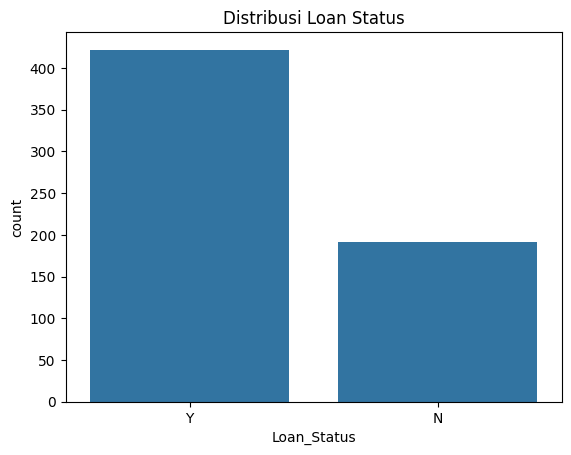

In [86]:
## Distribusi target
sns.countplot(x='Loan_Status', data=df)
plt.title("Distribusi Loan Status")
plt.show()

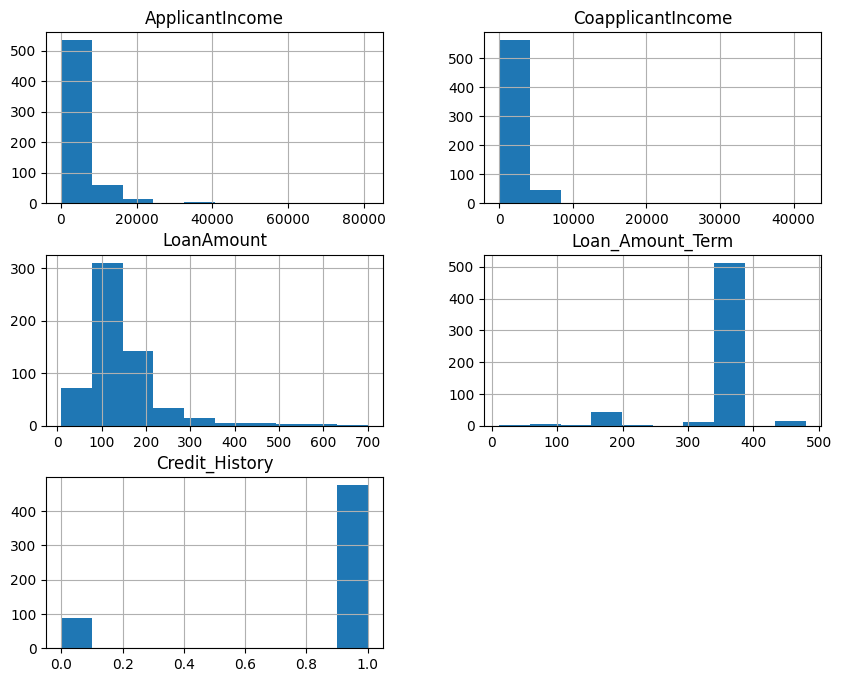

In [87]:
# Distribusi Numerik
df.select_dtypes(include=np.number).hist(figsize=(10,8))
plt.show()

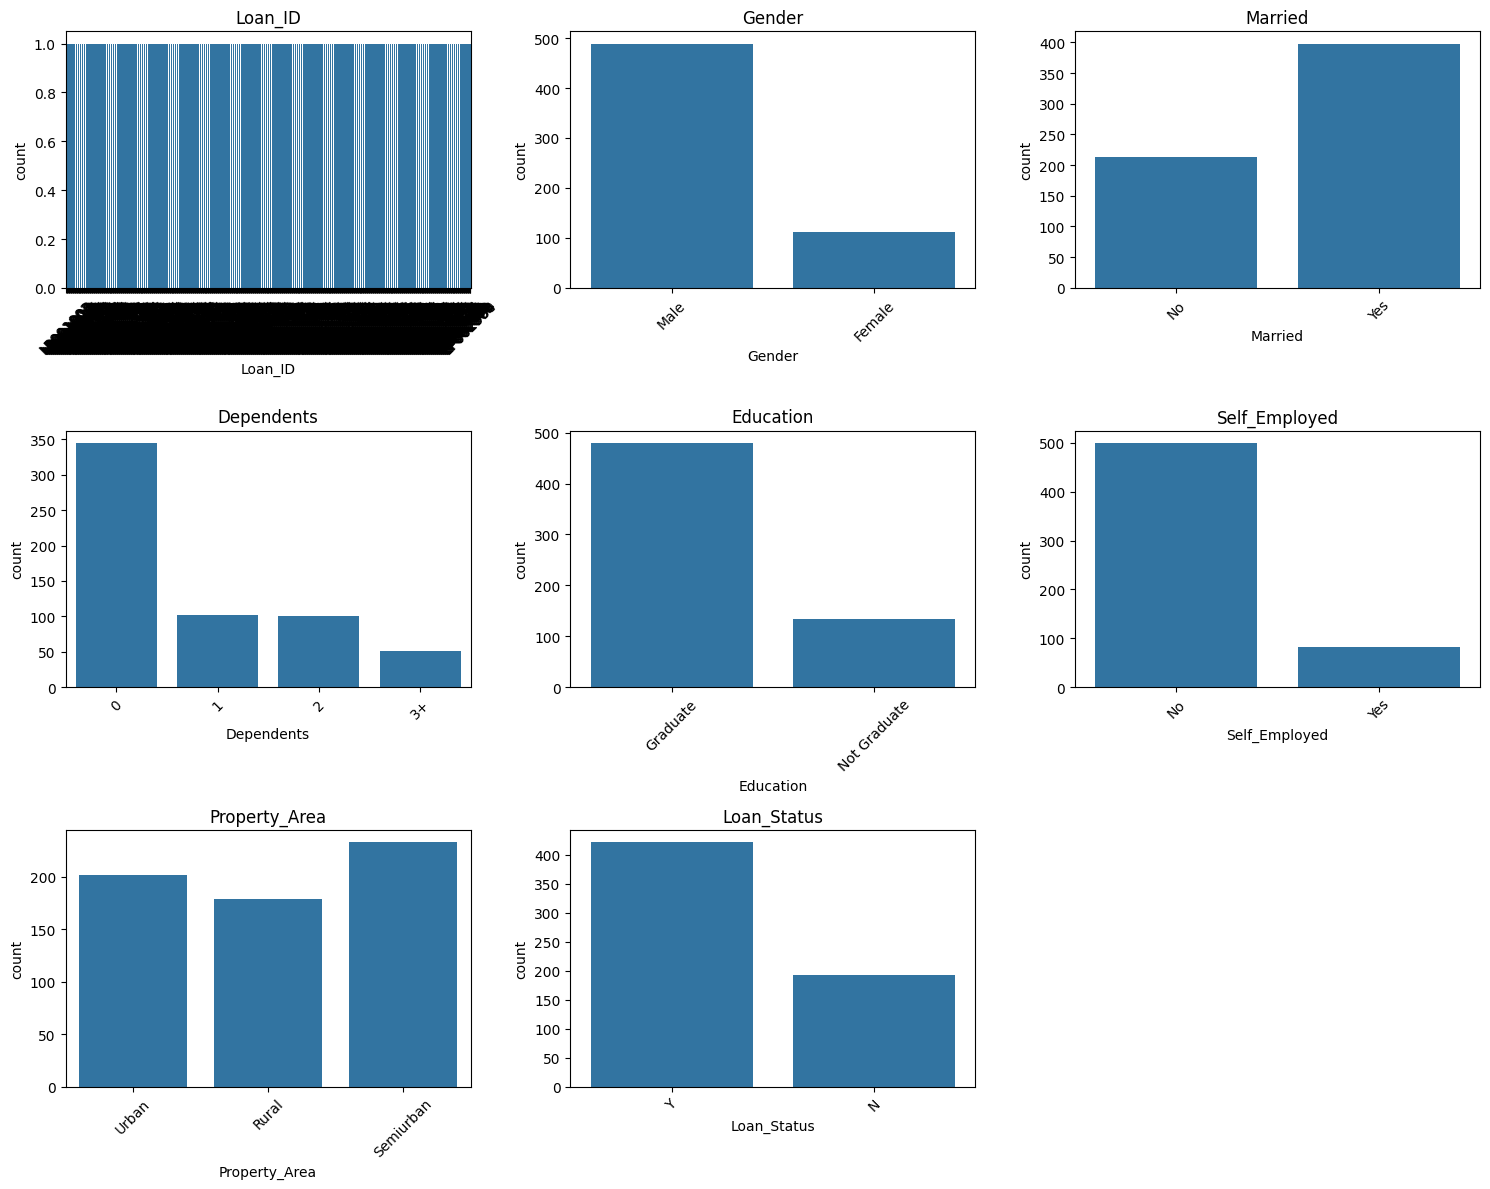

In [88]:
# Distribusi Kategorikal
cat_cols = df.select_dtypes(include='object').columns

n_cols = 3  # jumlah kolom subplot
n_rows = int(np.ceil(len(cat_cols) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

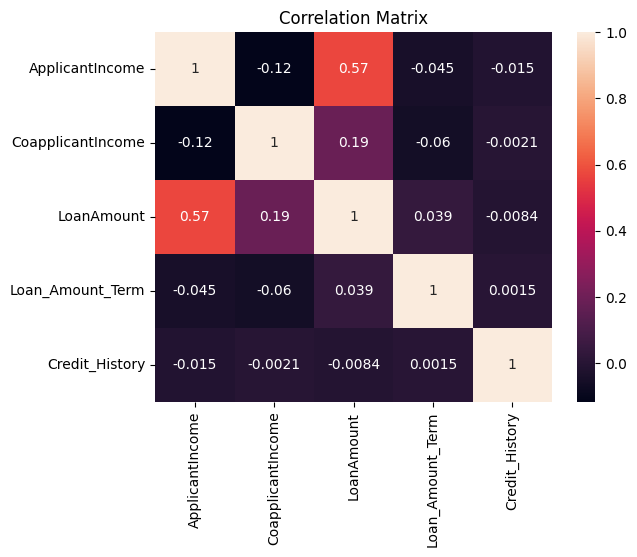

In [89]:
# Cek Korelasi
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [90]:
## Copy dataset asli untuk dilakukan data preprocessing
df_clean = df.copy()

## Menghapus kolom yang tidak diperlukan

In [91]:
df_clean.drop(columns=['Loan_ID'], inplace=True)

## Menghapus kolom yang memiliki tipe string

In [92]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

## Handle Missing Value

In [93]:
## Kategorikal
cat_cols = ['Gender','Married','Dependents','Self_Employed']

for col in cat_cols:
    df_clean[col].replace('nan', np.nan, inplace=True)
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

/tmp/ipykernel_2060/2687809295.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].replace('nan', np.nan, inplace=True)
/tmp/ipykernel_2060/2687809295.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [94]:
# Numerik
df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].mean(), inplace=True)
df_clean['Loan_Amount_Term'].fillna(df_clean['Loan_Amount_Term'].mean(), inplace=True)

/tmp/ipykernel_2060/1191686091.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].mean(), inplace=True)
/tmp/ipykernel_2060/1191686091.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [95]:
# Credit History
df_final['Credit_History'] = df_final['Credit_History'].astype(int)

## Menghapus data duplikat

In [96]:
df_clean.drop_duplicates(inplace=True)

## Validasi data setelah duplikat

In [97]:
print("Missing setelah cleaning:\n", df_clean.isnull().sum())

Missing setelah cleaning:
 Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


## Deteksi Penangan Outlier

In [98]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

z = np.abs(stats.zscore(df_clean[num_cols]))
df_clean = df_clean[(z < 3).all(axis=1)]

## Menormalisasi kategori agar semua formay menjadi seragam

In [99]:
df_clean['Gender'] = df_clean['Gender'].str.capitalize()
df_clean['Married'] = df_clean['Married'].str.capitalize()
df_clean['Self_Employed'] = df_clean['Self_Employed'].str.capitalize()

## Encoding

In [100]:
# Binary encoding
df_clean['Gender'] = df_clean['Gender'].map({'Male':1, 'Female':0})
df_clean['Married'] = df_clean['Married'].map({'Yes':1, 'No':0})
df_clean['Education'] = df_clean['Education'].map({'Graduate':1, 'Not Graduate':0})
df_clean['Self_Employed'] = df_clean['Self_Employed'].map({'Yes':1, 'No':0})
df_clean['Loan_Status'] = df_clean['Loan_Status'].map({'Y':1, 'N':0})

In [101]:
# Dependents
df_clean['Dependents'] = df_clean['Dependents'].replace('3+', 3).astype(int)

In [102]:
# One Hot Encoding
if 'Property_Area' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=['Property_Area'], drop_first=True)

In [103]:
# Mengubah boolean ke integer pada dataset
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

## Binning

In [104]:
df_clean['Income_Bin'] = pd.cut(df_clean['ApplicantIncome'], bins=4, labels=False)

## Normalisasi / standarisasi

In [105]:
scaler = StandardScaler()

df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

## Validasi Final

In [106]:
print("Missing:\n", df_clean.isnull().sum())
print("\nTipe data:\n", df_clean.dtypes)
print("\nUnique check:")
print(df_clean.nunique())

Missing:
 Gender                      0
Married                     0
Dependents                  0
Education                   0
Self_Employed               0
ApplicantIncome             0
CoapplicantIncome           0
LoanAmount                  0
Loan_Amount_Term            0
Credit_History             45
Loan_Status                 0
Property_Area_Semiurban     0
Property_Area_Urban         0
Income_Bin                  0
dtype: int64

Tipe data:
 Gender                       int64
Married                      int64
Dependents                   int64
Education                    int64
Self_Employed                int64
ApplicantIncome            float64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
Income_Bin                   int64
dtype: object

Unique check:
Gender                   

## Menyimpan dataset hasil preprocessing

In [107]:
df_final = df_clean.copy()

df_final.head()
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 577 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   577 non-null    int64  
 1   Married                  577 non-null    int64  
 2   Dependents               577 non-null    int64  
 3   Education                577 non-null    int64  
 4   Self_Employed            577 non-null    int64  
 5   ApplicantIncome          577 non-null    float64
 6   CoapplicantIncome        577 non-null    float64
 7   LoanAmount               577 non-null    float64
 8   Loan_Amount_Term         577 non-null    float64
 9   Credit_History           532 non-null    float64
 10  Loan_Status              577 non-null    int64  
 11  Property_Area_Semiurban  577 non-null    int64  
 12  Property_Area_Urban      577 non-null    int64  
 13  Income_Bin               577 non-null    int64  
dtypes: float64(5), int64(9)
memory 

In [108]:
df_final.to_csv('/content/sample_data/loan_clean.csv', index=False)